(-0.5, 473.5, 473.5, -0.5)

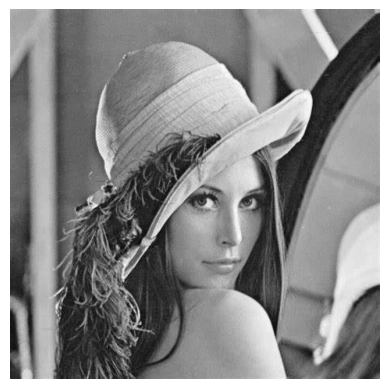

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

ig = cv2.imread(r"/content/lenna.jpg")
ig = cv2.cvtColor(ig, cv2.COLOR_BGR2GRAY)

plt.imshow(ig, cmap = 'grey')
plt.axis('off')

# **CANY EDGE DETECTION**

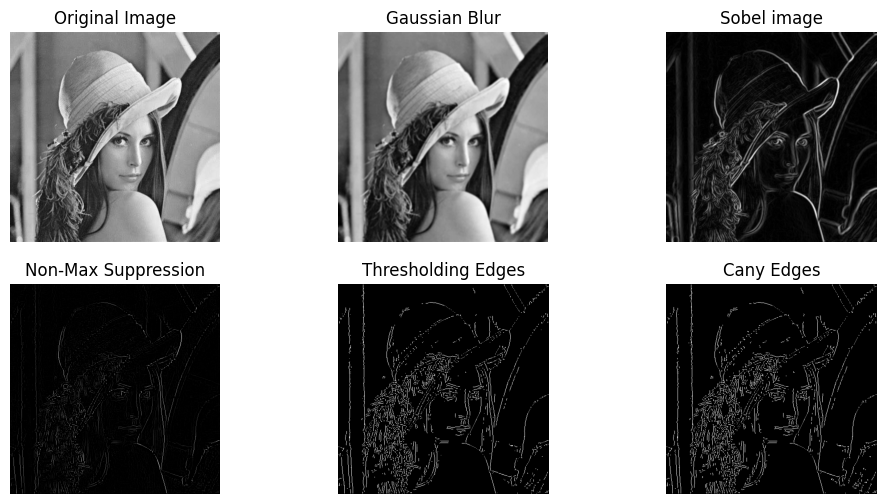

In [ ]:
blurred = cv2.GaussianBlur(ig, (5,5), 1.4)

Gx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
Gy = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
gradient_magnitude = np.sqrt(Gx**2 + Gy**2)
gradient_direction = np.arctan2(Gy, Gx)

suppressed = np.zeros_like(gradient_magnitude)
angle = gradient_direction * (180.0 / np.pi)
angle[angle < 0] += 180

rows, cols = gradient_magnitude.shape
for i in range(1, rows - 1):
    for j in range(1, cols - 1):
        try:
            q = 255
            r = 255
            if (0 <= angle[i, j] < 22.5) or (157.5 <= angle[i, j] <= 180):
                q = gradient_magnitude[i, j + 1]
                r = gradient_magnitude[i, j - 1]
            elif (22.5 <= angle[i, j] < 67.5):
                q = gradient_magnitude[i + 1, j - 1]
                r = gradient_magnitude[i - 1, j + 1]
            elif (67.5 <= angle[i, j] < 112.5):
                q = gradient_magnitude[i + 1, j]
                r = gradient_magnitude[i - 1, j]
            elif (112.5 <= angle[i, j] < 157.5):
                q = gradient_magnitude[i - 1, j - 1]
                r = gradient_magnitude[i + 1, j + 1]

            if (gradient_magnitude[i, j] >= q) and (gradient_magnitude[i, j] >= r):
                suppressed[i, j] = gradient_magnitude[i, j]
            else:
                suppressed[i, j] = 0
        except IndexError as e:
            pass

highThreshold = 50
lowThreshold = 25

strong_edges = (suppressed > highThreshold).astype(np.uint8) * 255
weak_edges = ((suppressed <= highThreshold) & (suppressed >= lowThreshold)).astype(np.uint8) * 255

final_edges = strong_edges.copy()
for i in range(1, rows - 1):
    for j in range(1, cols - 1):
        if weak_edges[i, j] == 255:
            if (strong_edges[i - 1:i + 2, j - 1:j + 2] == 255).any():
                final_edges[i, j] = 255


plt.figure(figsize=(12, 6))

plt.subplot(2,3,1)
plt.imshow(ig, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(blurred, cmap='gray')
plt.title("Gaussian Blur")
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(gradient_magnitude, cmap='gray')
plt.title("Sobel image")
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(suppressed, cmap='gray')
plt.title("Non-Max Suppression")
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(strong_edges, cmap='gray')
plt.title("Thresholding Edges")
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(final_edges, cmap='gray')
plt.title("Cany Edges")
plt.axis('off')

plt.savefig('canny.png')
plt.show()


# **Log and Dog Filters**

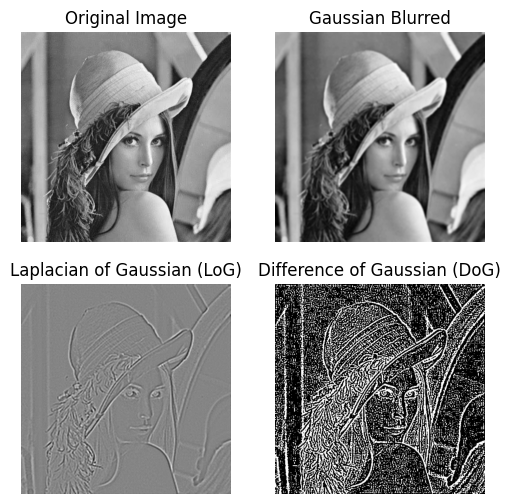

In [ ]:
sigma = 2.0
gaussian_blurred = cv2.GaussianBlur(ig, (5, 5), sigma)

log = cv2.Laplacian(gaussian_blurred, cv2.CV_64F)

sigma1, sigma2 = 1.0, 2.0
gaussian1 = cv2.GaussianBlur(ig, (5, 5), sigma1)
gaussian2 = cv2.GaussianBlur(ig, (5, 5), sigma2)
dog = gaussian1 - gaussian2

def zero_crossing_detection(log_img):
    rows, cols = log_img.shape
    edges = np.zeros(log_img.shape, dtype=np.uint8)

    for i in range(1, rows - 1):
        for j in range(1, cols - 1):
            patch = log_img[i-1:i+2, j-1:j+2]
            min_val = np.min(patch)
            max_val = np.max(patch)
            if min_val < 0 and max_val > 0:
                edges[i, j] = 255
    return edges

log_edges = zero_crossing_detection(log)
dog_edges = zero_crossing_detection(dog)

plt.figure(figsize=(6, 6))

plt.subplot(2,2,1)
plt.imshow(ig, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(gaussian_blurred, cmap='gray')
plt.title("Gaussian Blurred")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(log, cmap='gray')
plt.title("Laplacian of Gaussian (LoG)")
plt.axis("off")

# plt.subplot(2,3,4)
# plt.imshow(log_edges, cmap='gray')
# plt.title("LoG Zero-Crossings")
# plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(dog, cmap='gray')
plt.title("Difference of Gaussian (DoG)")
plt.axis("off")

# plt.subplot(2,3,6)
# plt.imshow(dog_edges, cmap='gray')
# plt.title("DoG Zero-Crossings")
# plt.axis("off")

plt.savefig('log&dog.jpg')
plt.show()


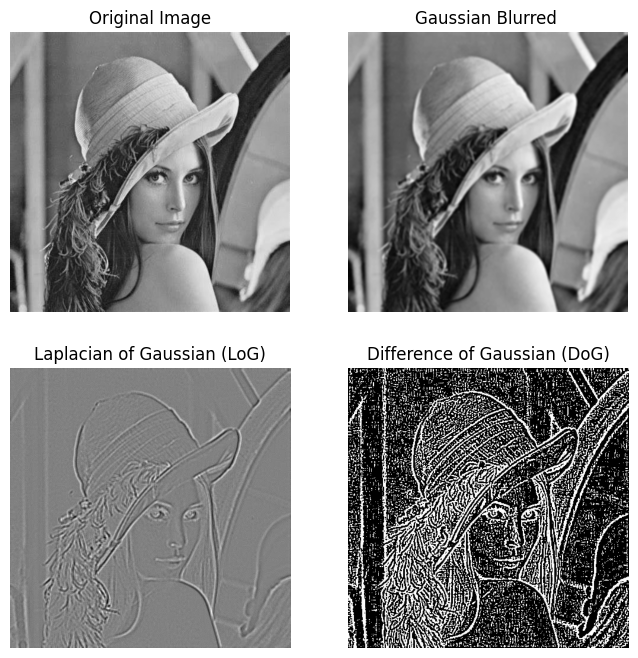

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def laplacian_of_gaussian(image, sigma=2.0):
    """Applies Laplacian of Gaussian (LoG) for edge detection."""
    # Step 1: Apply Gaussian Blur
    blurred = cv2.GaussianBlur(image, (5, 5), sigma)

    # Step 2: Apply Laplacian Operator
    log = cv2.Laplacian(blurred, cv2.CV_64F)

    # Step 3: Find Zero-Crossings for Edge Detection
    log_edges = zero_crossing_detection(log)

    return blurred, log, log_edges

def difference_of_gaussians(image, sigma1=1.0, sigma2=2.0):
    """Approximates LoG using the Difference of Gaussian (DoG)."""
    # Step 1: Apply Gaussian Blur with Two Different Sigmas
    gaussian1 = cv2.GaussianBlur(image, (5, 5), sigma1)
    gaussian2 = cv2.GaussianBlur(image, (5, 5), sigma2)

    # Step 2: Compute DoG by Subtracting Two Blurred Images
    dog = gaussian1 - gaussian2

    # Step 3: Find Zero-Crossings for Edge Detection
    dog_edges = zero_crossing_detection(dog)

    return gaussian1, gaussian2, dog, dog_edges

def zero_crossing_detection(log_img):
    """Finds edges by detecting zero-crossings in LoG or DoG filtered image."""
    rows, cols = log_img.shape
    edges = np.zeros(log_img.shape, dtype=np.uint8)

    for i in range(1, rows - 1):
        for j in range(1, cols - 1):
            patch = log_img[i-1:i+2, j-1:j+2]  # 3×3 neighborhood
            min_val = np.min(patch)
            max_val = np.max(patch)
            if min_val < 0 and max_val > 0:
                edges[i, j] = 255  # Mark as edge if zero-crossing occurs

    return edges

# Load image in grayscale
image = cv2.imread(r"/content/lenna.jpg", cv2.IMREAD_GRAYSCALE)

# Apply LoG Edge Detection
blurred_log, log, log_edges = laplacian_of_gaussian(image)

# Apply DoG Edge Detection
gaussian1, gaussian2, dog, dog_edges = difference_of_gaussians(image)

# Display Results
plt.figure(figsize=(8, 8))

plt.subplot(2,2,1), plt.imshow(image, cmap='gray'), plt.title("Original Image"), plt.axis("off")
plt.subplot(2,2,2), plt.imshow(blurred_log, cmap='gray'), plt.title("Gaussian Blurred "), plt.axis("off")
plt.subplot(2,2,3), plt.imshow(log, cmap='gray'), plt.title("Laplacian of Gaussian (LoG)"), plt.axis("off")
# plt.subplot(2,3,4), plt.imshow(log_edges, cmap='gray'), plt.title("LoG Zero-Crossings"), plt.axis("off")
plt.subplot(2,2,4), plt.imshow(dog, cmap='gray'), plt.title("Difference of Gaussian (DoG)"), plt.axis("off")
# plt.subplot(2,3,6), plt.imshow(dog_edges, cmap='gray'), plt.title("DoG Zero-Crossings"), plt.axis("off")

plt.savefig('log&dog3.jpg')
plt.show()


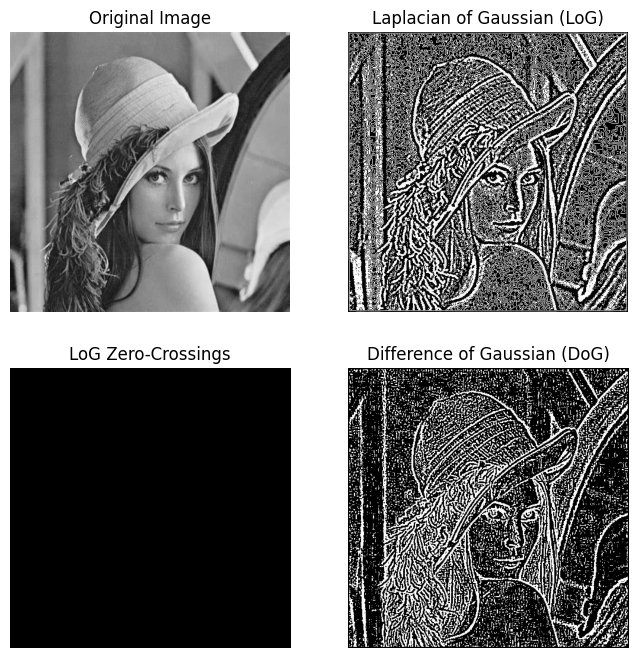

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load the image
ig = cv2.imread(r'/content/lenna.jpg', cv2.IMREAD_GRAYSCALE)

# Create Gaussian Kernel
def create_gaussian_kernel(size, sigma):
    k = size // 2
    kernel = np.zeros((size, size), dtype=np.float32)
    for x in range(-k, k+1):
        for y in range(-k, k+1):
            kernel[x+k, y+k] = (1/(2*np.pi*sigma**2)) * np.exp(-(x**2 + y**2) / (2*sigma**2))
    return kernel / np.sum(kernel)

# Apply Kernel
def apply_kernel(image, kernel):
    rows, cols = image.shape
    k = kernel.shape[0] // 2
    blurred = np.zeros_like(image)
    for i in range(k, rows-k):
        for j in range(k, cols-k):
            region = image[i-k:i+k+1, j-k:j+k+1]
            blurred[i, j] = np.sum(region * kernel)
    return blurred

# Apply Laplacian
def apply_laplacian(image):
    laplacian_kernel = np.array([[0,  1, 0],
                                 [1, -4, 1],
                                 [0,  1, 0]], dtype=np.float32)
    return apply_kernel(image, laplacian_kernel)

# Laplacian of Gaussian (LoG)
def laplacian_of_gaussian(image, kernel_size, sigma):
    gaussian_kernel = create_gaussian_kernel(kernel_size, sigma)
    blurred = apply_kernel(image, gaussian_kernel)
    log_image = apply_laplacian(blurred)
    return log_image

# Difference of Gaussian (DoG)
def difference_of_gaussian(image, kernel_size, sigma1, sigma2):
    kernel1 = create_gaussian_kernel(kernel_size, sigma1)
    kernel2 = create_gaussian_kernel(kernel_size, sigma2)
    gaussian1 = apply_kernel(image, kernel1)
    gaussian2 = apply_kernel(image, kernel2)
    dog_image = gaussian1 - gaussian2
    return dog_image

# Zero-Crossing Detection
def zero_crossing_detection(log_img):
    rows, cols = log_img.shape
    edges = np.zeros(log_img.shape, dtype=np.uint8)

    for i in range(1, rows - 1):
        for j in range(1, cols - 1):
            patch = log_img[i-1:i+2, j-1:j+2]  # 3x3 patch around the pixel
            min_val = np.min(patch)
            max_val = np.max(patch)
            if min_val < 0 and max_val > 0:
                edges[i, j] = 255  # Mark as edge
    return edges

# Apply LoG
log_image = laplacian_of_gaussian(ig, 5, 2.0)
log_edges = zero_crossing_detection(log_image)

# Apply DoG
dog_image = difference_of_gaussian(ig, 5, 1.0, 2.0)
dog_edges = zero_crossing_detection(dog_image)

# Plot the results
plt.figure(figsize=(8, 8))

plt.subplot(2,2,1)
plt.imshow(ig, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(log_image, cmap='gray')
plt.title("Laplacian of Gaussian (LoG)")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(log_edges, cmap='gray')
plt.title("LoG Zero-Crossings")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(dog_image, cmap='gray')
plt.title("Difference of Gaussian (DoG)")
plt.axis("off")

# plt.subplot(2,3,6)
# plt.imshow(dog_edges, cmap='gray')
# plt.title("DoG Zero-Crossings")
# plt.axis("off")

plt.show()


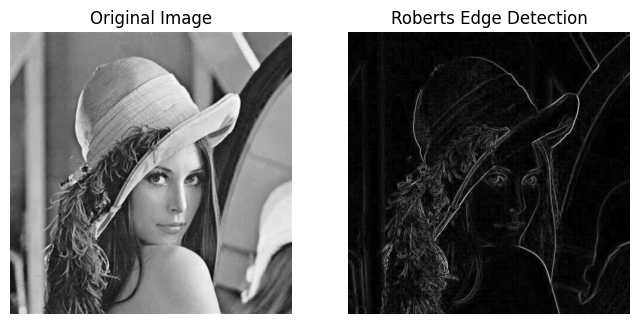

In [ ]:
def roberts_edge_detection(image):

    image = image.astype(np.float32)

    roberts_x = np.array([[1, 0], [0, -1]], dtype=np.float32)
    roberts_y = np.array([[0, 1], [-1, 0]], dtype=np.float32)

    Gx = cv2.filter2D(image, -1, roberts_x)
    Gy = cv2.filter2D(image, -1, roberts_y)

    edge_magnitude = np.sqrt(Gx**2 + Gy**2)

    edge_magnitude = np.uint8(255 * edge_magnitude / np.max(edge_magnitude))

    return edge_magnitude


roberts_edges = roberts_edge_detection(ig)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(ig, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(roberts_edges, cmap='gray')
plt.title("Roberts Edge Detection")
plt.axis("off")

plt.savefig('roberts.png')
plt.show()


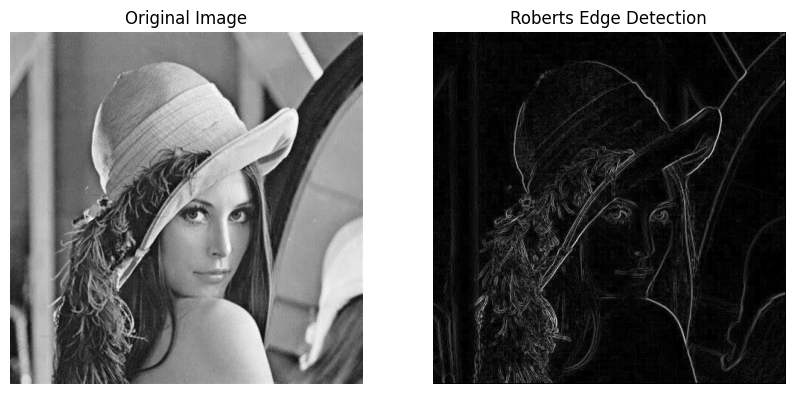

In [ ]:
roberts_x = np.array([[1, 0], [0, -1]], dtype=np.float32)
roberts_y = np.array([[0, 1], [-1, 0]], dtype=np.float32)

row, col = ig.shape

roberts_x_result = np.zeros_like(ig, dtype=np.float32)
roberts_y_result = np.zeros_like(ig, dtype=np.float32)

for i in range(row - 1):
    for j in range(col - 1):
        kernel = ig[i:i + 2, j:j + 2]
        roberts_x_result[i, j] = np.sum(kernel * roberts_x)
        roberts_y_result[i, j] = np.sum(kernel * roberts_y)

mag = np.sqrt((roberts_x_result ** 2) + (roberts_y_result ** 2))

mag = np.uint8(255 * mag / (np.max(mag) - np.min(mag)))

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(ig, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mag, cmap='gray')
plt.title("Roberts Edge Detection")
plt.axis('off')

# plt.savefig('')
plt.show()


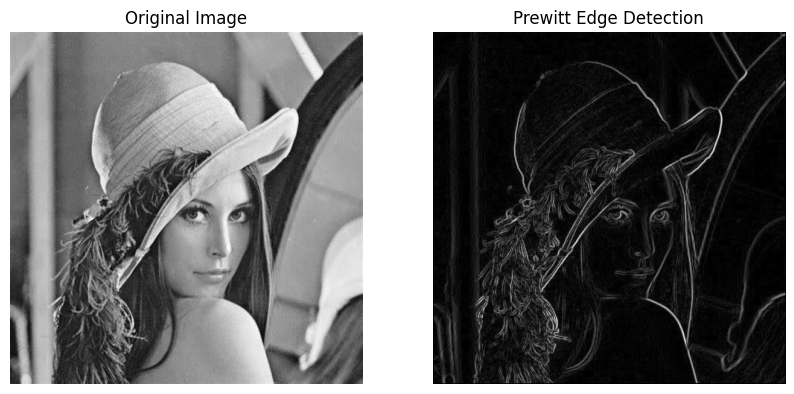

In [ ]:

prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
prewitt_y = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=np.float32)

row, col = ig.shape

prewitt_x_result = np.zeros_like(ig, dtype=np.float32)
prewitt_y_result = np.zeros_like(ig, dtype=np.float32)

for i in range(1, row - 1):
    for j in range(1, col - 1):
        kernel = ig[i - 1:i + 2, j - 1:j + 2]
        prewitt_x_result[i, j] = np.sum(kernel * prewitt_x)
        prewitt_y_result[i, j] = np.sum(kernel * prewitt_y)

mag = np.sqrt((prewitt_x_result ** 2) + (prewitt_y_result ** 2))

mag = np.uint8(255 * mag / (np.max(mag) - np.min(mag)))

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(ig, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mag, cmap='gray')
plt.title("Prewitt Edge Detection")
plt.axis('off')

plt.savefig('prewitt.png')
plt.show()
